#TASK 1 — DATA LOADING & EXPLORATION

In [2]:
#importing dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Load the CSV file using Pandas 
df= pd.read_csv('Housing.csv')

In [5]:
#Display the first 10 rows
print(df.head(10))

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [6]:
#check how many rows and how many columns
print(f"\n(Rows and Columns): {df.shape}")
print(f" Total Rows: {df.shape[0]}")
print(f" Total Columns: {df.shape[1]}")


(Rows and Columns): (545, 13)
 Total Rows: 545
 Total Columns: 13


In [7]:
#finding target column & features
print("\nTarget Column: price")
print("Feature Columns:")
features = [col for col in df.columns if col != 'price']
for i in features:
    print(f"  : {i}")


Target Column: price
Feature Columns:
  : area
  : bedrooms
  : bathrooms
  : stories
  : mainroad
  : guestroom
  : basement
  : hotwaterheating
  : airconditioning
  : parking
  : prefarea
  : furnishingstatus


In [8]:
#check missing values

print("\nMissing Values (in each column):")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")


Missing Values (in each column):
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total Missing Values: 0


#Task 2 — Data Cleaning

In [9]:
#Handling missing values by filling it with mean or mode values

# Numeric columns is filled by "mean" values
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)

# Categorical columns is filled by "mode" values
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [11]:
# remove duplicate rows
df.drop_duplicates(inplace=True)

In [10]:
# One-Hot Encoding (for 0/1 or 2 options)
print("\nEncoding categorical columns:")

binary_cols = [
    'mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea'
]

for col in binary_cols:
    if col in df.columns:
        # Encode only if values are still yes/no
        if df[col].dtype == 'object':
            df[col] = df[col].map({'yes': 1, 'no': 0})
    else:
        print(f"Warning: '{col}' column not found.")

# One-Hot Encoding (for 3 options)
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(
        df,
        columns=['furnishingstatus'],
        prefix='furnishingstatus',
        drop_first=False,
        dtype=int
    )
else:
    print("'furnishingstatus' is already encoded or not present.")

print(df.columns.tolist())


Encoding categorical columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [12]:
# Keep only meaningful columns

print("\nSelecting meaningful features (using correlation values):")
# finding correlation of every feature with price
correlation_with_price = df.corr()['price'].drop('price').abs()
print("\n correlation of features with price:")
print(correlation_with_price.sort_values(ascending=False))

#drop those having correaltion<0.05 (or threshold)
threshold = 0.05
weak_features = correlation_with_price[
    correlation_with_price < threshold
].index.tolist()
print(f"\n Drop weak features (having correlation <(threshold))")
for f in weak_features:
    print(f" {f}: {correlation_with_price[f]:.4f}")
df.drop(columns=weak_features, inplace=True)

print(f"\nFinal Meaningful Columns ({len(df.columns)}):")
for col in df.columns:
    if col != 'price':
        print(f" {col}: {correlation_with_price.get(col, 'TARGET'):.4f}")

print(f"\nDataset shape after removing weak features: {df.shape}")


Selecting meaningful features (using correlation values):

 correlation of features with price:
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
furnishingstatus_unfurnished       0.280587
guestroom                          0.255517
furnishingstatus_furnished         0.229350
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64

 Drop weak features (having correlation <(threshold))

Final Meaningful Columns (15):
 area: 0.5360
 bedrooms: 0.3665
 bathrooms: 0.5175
 stories: 0.4207
 mainroad: 0.2969
 guestroom: 0.2555
 basement: 0.1871
 hotwaterheating: 0.0931
 airconditioning: 0.4530

#Task 3 — Model Building 

In [13]:
# separating features & target before Train-test splt
X = df.drop('price', axis=1)   # Features
y = df['price']                  # Target
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
 
# Train-Test Split (80/20) size making
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% test
    random_state=42 
)

Features (X) shape: (545, 14)
Target (y) shape: (545,)


In [14]:
#Model-1 : Linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
 
# Calculating metrics
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2   = r2_score(y_test, y_pred_lr)
#Printing results
print(f"\nLinear Regression Results:")
print(f"   MAE  (Mean Absolute Error):  {lr_mae:,.2f}")
print(f"   RMSE (Root Mean Sq Error):   {lr_rmse:,.2f}")
print(f"   R²   (R-Squared Score):      {lr_r2:.4f}")
print(f"   Accuracy: {lr_r2 * 100:.2f}%")


Linear Regression Results:
   MAE  (Mean Absolute Error):  970,043.40
   RMSE (Root Mean Sq Error):   1,324,506.96
   R²   (R-Squared Score):      0.6529
   Accuracy: 65.29%


In [15]:
print("Model-2: Random Forest Regressor")
rf_model = RandomForestRegressor(
    n_estimators=100,   # 100 trees
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
 
# Metrics calculate karo
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)
 #printing results
print(f"Random Forest Results:")
print(f"MAE  (Mean Absolute Error):  {rf_mae:,.2f}")
print(f"RMSE (Root Mean Sq Error):   {rf_rmse:,.2f}")
print(f"R²  (R-Squared Score):      {rf_r2:.4f}")
print(f"Accuracy: {rf_r2 * 100:.2f}%")

Model-2: Random Forest Regressor
Random Forest Results:
MAE  (Mean Absolute Error):  1,019,527.55
RMSE (Root Mean Sq Error):   1,400,219.42
R²  (R-Squared Score):      0.6121
Accuracy: 61.21%


In [16]:
print("MODEL COMPARISON")
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [f"{lr_mae:,.0f}", f"{lr_rmse:,.0f}", f"{lr_r2:.4f}"],
    'Random Forest': [f"{rf_mae:,.0f}", f"{rf_rmse:,.0f}", f"{rf_r2:.4f}"]
})
print(comparison.to_string(index=False))
 
if rf_r2 > lr_r2:
    print("\nRandom Forest is better model (Based on R² Score)")
else:
    print("\nLinear Regression is better model (Based on R² Score)")

MODEL COMPARISON
  Metric Linear Regression Random Forest
     MAE           970,043     1,019,528
    RMSE         1,324,507     1,400,219
R² Score            0.6529        0.6121

Linear Regression is better model (Based on R² Score)


#Task 4 — Visualization 

In [17]:
# setting figures before using for charts or plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

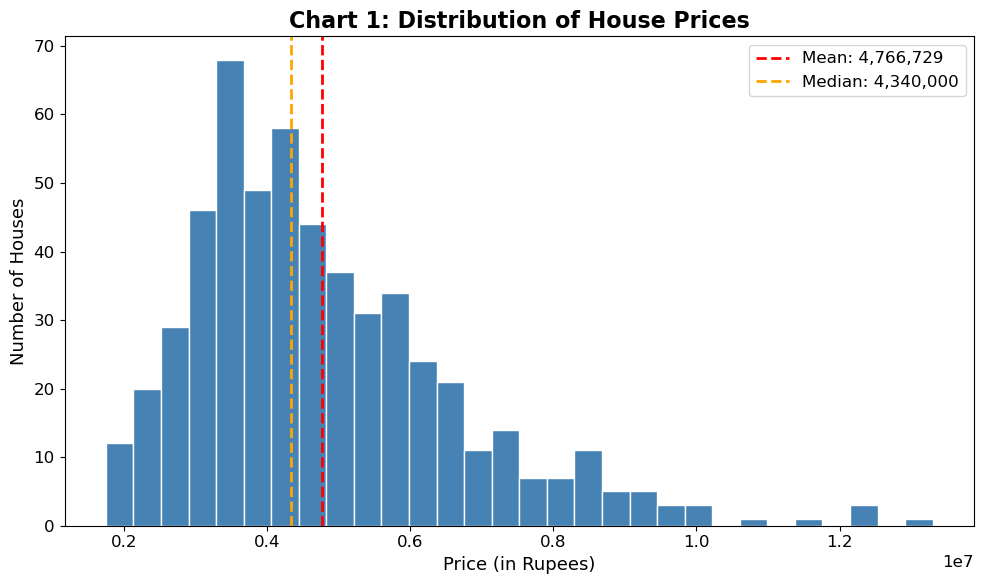

Chart 1 saved: chart1_price_distribution.png


In [18]:
#chart-1 : Distribution of House Prices
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='white')
plt.title('Chart 1: Distribution of House Prices', fontsize=16, fontweight='bold')
plt.xlabel('Price (in Rupees)', fontsize=13)
plt.ylabel('Number of Houses', fontsize=13)
plt.axvline(df['price'].mean(), color='red', linestyle='--',
            linewidth=2, label=f"Mean: {df['price'].mean():,.0f}")
plt.axvline(df['price'].median(), color='orange', linestyle='--',
            linewidth=2, label=f"Median: {df['price'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved: chart1_price_distribution.png")

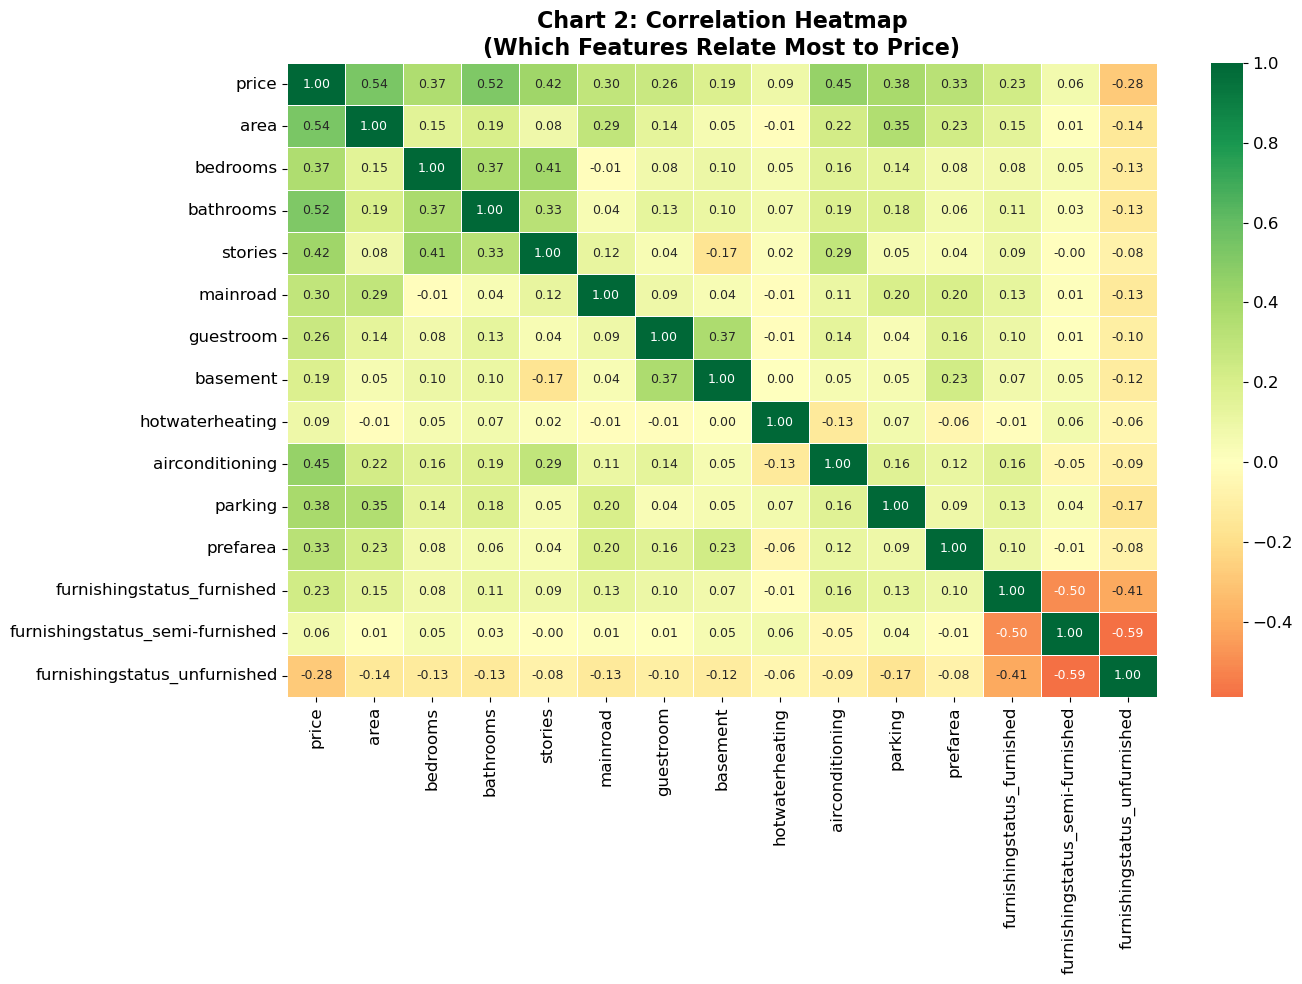

Chart 2 saved: chart2_correlation_heatmap.png
Top Features correlated with Price:
   area                                +0.536  ----------
   bathrooms                           +0.518  ----------
   airconditioning                     +0.453  ---------
   stories                             +0.421  --------
   parking                             +0.384  -------
   bedrooms                            +0.366  -------
   prefarea                            +0.330  ------
   mainroad                            +0.297  -----
   guestroom                           +0.256  -----
   furnishingstatus_furnished          +0.229  ----
   basement                            +0.187  ---
   hotwaterheating                     +0.093  -
   furnishingstatus_semi-furnished     +0.064  -
   furnishingstatus_unfurnished        -0.281  -----


In [19]:
#chart-2 : Correlation heatmap (shows how strongly features realate to prices)

plt.figure(figsize=(14, 10))
# Find correlation of numerical columns
corr_matrix = df.corr()
# Heatmap making
sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt='.2f',      
    cmap='RdYlGn', 
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Chart 2: Correlation Heatmap\n(Which Features Relate Most to Price)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved: chart2_correlation_heatmap.png")
 
# Printing top correlations with price
print("Top Features correlated with Price:")
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
for feature, corr in price_corr.items():
    bar = "-" * int(abs(corr) * 20)
    print(f"   {feature:<35} {corr:+.3f}  {bar}")

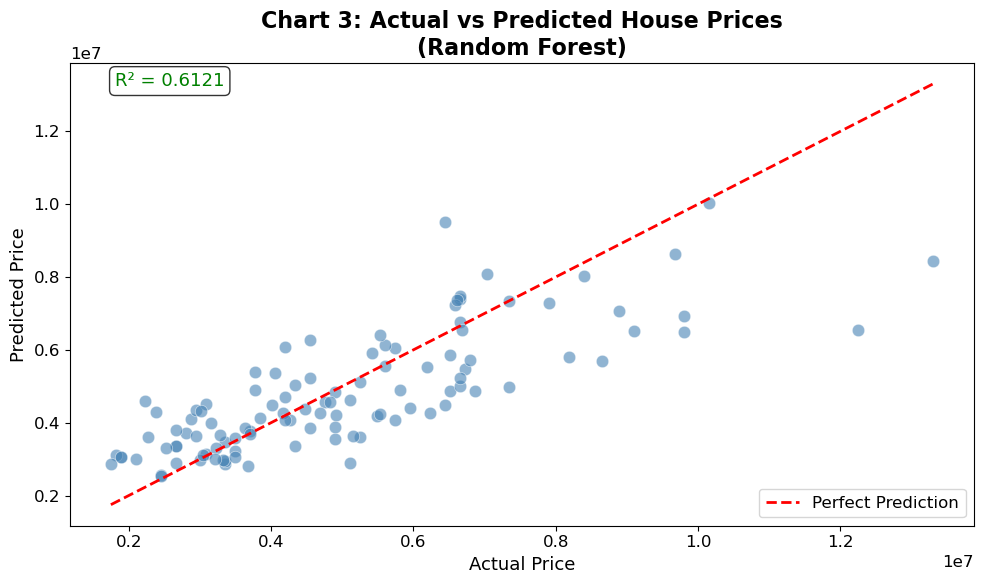

Chart 3 saved: chart3_actual_vs_predicted.png


In [20]:
#Chart-3: Actual vs predicted house prices (using random forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue',
            edgecolors='white', linewidth=0.5, s=80)
 
# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')
 
plt.title('Chart 3: Actual vs Predicted House Prices\n(Random Forest)',
          fontsize=16, fontweight='bold')
plt.xlabel('Actual Price', fontsize=13)
plt.ylabel('Predicted Price', fontsize=13)
plt.legend()
# Adding R² score to the chart
plt.text(0.05, 0.95, f'R² = {rf_r2:.4f}',
         transform=plt.gca().transAxes,
         fontsize=13, color='green',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
 
plt.tight_layout()
plt.savefig('chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved: chart3_actual_vs_predicted.png")

#Task 5 — Insights & Summary

#Insights
About the dataset:-
     • Total houses analyzed: 545, Features used: 12,  Price range: ₹1,750,000 to ₹13,300,000, Average price: ₹4,766,729
   
#summary :- 
     The three features that influence house price the most are area, bathrooms, and air conditioning, with plot area standing out as by far the strongest
     driver of price, followed by the number of bathrooms and whether the house has air conditioning. 
     In plain terms, our Random Forest model explains 
     about 61% of the variation in house prices (R² = 0.61) and is typically off by roughly ₹1,019,528 per house, while the simpler Linear Regression model
     performs similarly, explaining about 65% of price variation. This means the models are reasonably useful for getting a ballpark estimate but should
     not be treated as exact valuations. 
     One interesting finding from the analysis is that the number of bedrooms has much less impact on price than expected. 
     So, Once the plot area is taken into account, houses with more bedrooms do not consistently sell for higher prices, whereas amenities such as 
     air conditioning have a stronger positive influence on price.
     Based on these findings, I recommend that real estate businesses focus on plot area and bathroom count when pricing and marketing properties, 
     while also highlighting features such as air conditioning and preferred-area locations, as these factors consistently contribute to higher property values.

In [21]:
import os

print(os.getcwd())

C:\Users\Mohit Raj\ HousePricePrediction_[Mohit Raj]


In [ ]:
import shutil
import os

current_folder = os.getcwd()
parent_folder = os.path.dirname(current_folder)

zip_path = shutil.make_archive(
    base_name=os.path.join(parent_folder, "HousePricePrediction_[Mohit Raj]"),
    format="zip",
    root_dir=current_folder
)

print("ZIP created successfully!")
print("Saved at:", zip_path)